# <center> Module 8: Recurrent Neural Networks</center>
##  <center>Predict the next word in a sentence from Shakespeare <br> Keras/TensorFow RNN </center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

Use python to create an RNN, specifically using LSTM layers, that predicts the next word in a phrase from Shakespeare

Some additional LSTM References:
- Illustrated Guide to LSTM's and GRU's: A step by step explanation
<br> https://www.youtube.com/watch?v=8HyCNIVRbSU

- Additional Reading: LSTM From Scratch
<br> https://d2l.ai/chapter_recurrent-modern/lstm.html#implementation-from-scratch


- Original LSTM Paper:
<br> https://www.bioinf.jku.at/publications/older/2604.pdf

In [2]:
#pip install -U tensorflow

In [73]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [75]:
import tensorflow as tf
print(tf.__version__)

2.15.0


### 1. Open and Read the text file containing Shakespeare poetry

In [6]:
with open('shakespeare.txt', 'r') as file: 
    text = file.read() 
    lines = text.lower().split('\n')

In [79]:
print(len(lines))

179


In [7]:
print(text[0:200])

From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou contracted to thine own 


In [8]:
lines

['from fairest creatures we desire increase,',
 "that thereby beauty's rose might never die,",
 'but as the riper should by time decease,',
 'his tender heir might bear his memory:',
 'but thou contracted to thine own bright eyes,',
 "feed'st thy light's flame with self-substantial fuel,",
 'making a famine where abundance lies,',
 'thy self thy foe, to thy sweet self too cruel:',
 "thou that art now the world's fresh ornament,",
 'and only herald to the gaudy spring,',
 'within thine own bud buriest thy content,',
 "and, tender churl, mak'st waste in niggarding:",
 '   pity the world, or else this glutton be,',
 "   to eat the world's due, by the grave and thee.",
 'when forty winters shall besiege thy brow,',
 "and dig deep trenches in thy beauty's field,",
 "thy youth's proud livery so gazed on now,",
 'will be a tattered weed of small worth held:',
 'then being asked, where all thy beauty lies,',
 'where all the treasure of thy lusty days;',
 'to say, within thine own deep sunken e

### 2. Break the lines down into single words stored in an array 
This process:
1. Removes all punctuation including tabs and new lines
2. Converts all words to lower case
3. Splits the input string into words using spaces as the separator

In [10]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
words= text_to_word_sequence(text)

In [11]:
words

['from',
 'fairest',
 'creatures',
 'we',
 'desire',
 'increase',
 'that',
 'thereby',
 "beauty's",
 'rose',
 'might',
 'never',
 'die',
 'but',
 'as',
 'the',
 'riper',
 'should',
 'by',
 'time',
 'decease',
 'his',
 'tender',
 'heir',
 'might',
 'bear',
 'his',
 'memory',
 'but',
 'thou',
 'contracted',
 'to',
 'thine',
 'own',
 'bright',
 'eyes',
 "feed'st",
 'thy',
 "light's",
 'flame',
 'with',
 'self',
 'substantial',
 'fuel',
 'making',
 'a',
 'famine',
 'where',
 'abundance',
 'lies',
 'thy',
 'self',
 'thy',
 'foe',
 'to',
 'thy',
 'sweet',
 'self',
 'too',
 'cruel',
 'thou',
 'that',
 'art',
 'now',
 'the',
 "world's",
 'fresh',
 'ornament',
 'and',
 'only',
 'herald',
 'to',
 'the',
 'gaudy',
 'spring',
 'within',
 'thine',
 'own',
 'bud',
 'buriest',
 'thy',
 'content',
 'and',
 'tender',
 'churl',
 "mak'st",
 'waste',
 'in',
 'niggarding',
 'pity',
 'the',
 'world',
 'or',
 'else',
 'this',
 'glutton',
 'be',
 'to',
 'eat',
 'the',
 "world's",
 'due',
 'by',
 'the',
 'grav

In [12]:
len(words)

1345

In [13]:
import pandas as pd
word_series = pd.Series(words)

# Use value_counts() to get the count of each unique word
word_counts = word_series.value_counts()

# Create a DataFrame from the counts
word_df = pd.DataFrame({'Word': word_counts.index, 'Count': word_counts.values})

# See count of words in poem
word_df

,Word,Count
0,thou,45
1,the,40
2,and,36
3,thy,36
4,to,28
...,...,...
575,sap,1
576,there,1
577,leads,1
578,resting,1


### 3. Create tokens for each word, i.e. assign it a spot in an array

The sequences function creates a string representing the order of the words as they appear in the poem stacked together.
This tool orders the words by frequency with the most common words occuring in the lowest keys of the dictionary

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(words)

tokens = tokenizer.word_index

In [16]:
tokens

{'thou': 1,
 'the': 2,
 'thy': 3,
 'and': 4,
 'to': 5,
 'that': 6,
 'in': 7,
 'of': 8,
 'thee': 9,
 'self': 10,
 'be': 11,
 'with': 12,
 'for': 13,
 'his': 14,
 'thine': 15,
 'when': 16,
 'not': 17,
 'but': 18,
 'so': 19,
 'beauty': 20,
 'if': 21,
 'which': 22,
 'art': 23,
 'world': 24,
 'it': 25,
 'from': 26,
 "beauty's": 27,
 'a': 28,
 'then': 29,
 'all': 30,
 'make': 31,
 'is': 32,
 'do': 33,
 'as': 34,
 'by': 35,
 'time': 36,
 'where': 37,
 'or': 38,
 'on': 39,
 'were': 40,
 'she': 41,
 'one': 42,
 'die': 43,
 'sweet': 44,
 'now': 45,
 'this': 46,
 'will': 47,
 'see': 48,
 'another': 49,
 'dost': 50,
 'love': 51,
 'why': 52,
 'doth': 53,
 'still': 54,
 'ten': 55,
 'i': 56,
 'should': 57,
 'eyes': 58,
 'look': 59,
 'who': 60,
 'age': 61,
 'those': 62,
 'what': 63,
 'times': 64,
 'shouldst': 65,
 'own': 66,
 'fresh': 67,
 'shall': 68,
 'being': 69,
 'treasure': 70,
 'an': 71,
 'shame': 72,
 'how': 73,
 'more': 74,
 'use': 75,
 'fair': 76,
 'my': 77,
 'glass': 78,
 'whose': 79,
 'some

In [17]:
''' Let's see how many words are in the "library" to train on.
The +1 is required, because later on when using to_categorical, 
a preprocessing step on the target data, it creates size - 1 columns, 
so we have to account for that somewhere, and we can do that here so there are enough target columns.
'''

vocabulary_size = len(tokens) + 1
vocabulary_size

581

### Build Sequences
#### Now create ordered sequences of the words for prediction

In [19]:
# Convert the phrases of words as their new token 
# value instead of words
sequences = tokenizer.texts_to_sequences(lines)
sequences

[[26, 189, 190, 191, 97, 98],
 [6, 99, 27, 192, 100, 101, 43],
 [18, 34, 2, 193, 57, 35, 36, 194],
 [14, 102, 103, 100, 104, 14, 195],
 [18, 1, 196, 5, 15, 66, 197, 58],
 [198, 3, 199, 200, 12, 10, 201, 202],
 [203, 28, 204, 37, 205, 105],
 [3, 10, 3, 206, 5, 3, 44, 10, 106, 207],
 [1, 6, 23, 45, 2, 107, 67, 208],
 [4, 209, 210, 5, 2, 211, 212],
 [108, 15, 66, 213, 214, 3, 215],
 [4, 102, 216, 217, 109, 7, 218],
 [219, 2, 24, 38, 110, 46, 220, 11],
 [5, 221, 2, 107, 222, 35, 2, 223, 4, 9],
 [16, 224, 225, 68, 226, 3, 227],
 [4, 228, 111, 229, 7, 3, 27, 230],
 [3, 231, 232, 233, 19, 234, 39, 45],
 [47, 11, 28, 235, 236, 8, 237, 238, 239],
 [29, 69, 240, 37, 30, 3, 20, 105],
 [37, 30, 2, 70, 8, 3, 112, 241],
 [5, 242, 108, 15, 66, 111, 243, 58],
 [40, 71, 30, 244, 72, 4, 245, 113],
 [73, 114, 74, 113, 246, 3, 27, 75],
 [21, 1, 247, 248, 14, 76, 115, 8, 249],
 [68, 116, 77, 117, 4, 31, 77, 118, 250, 251],
 [252, 14, 20, 35, 253, 15],
 [46, 40, 5, 11, 119, 120, 16, 1, 23, 118],
 [4, 48, 3,

Can use this embedding to call to display specific words in the dictionary at specific locations.
In this example, 581 is outside the range of the embedding, so does not return a word.

In [77]:
_list=[26,189,581]
for k, v in tokens.items():    
    if v in _list:
        print(v,k)

26 from
189 fairest


Find the location of specific words in the embedding:

In [23]:
_list=['trees','thou']
for k, v in tokens.items():    
    if k in _list:
        print(k,v)

thou 1
trees 552


### Build Sub-Sequences
#### This builds a series of strings to show the next words in the phrase, allowing the LSTM model to learn.

In [25]:
subsequences = []

for sequence in sequences:
    for i in range(1, len(sequence)):
        subsequence = sequence[:i+1]
        subsequences.append(subsequence)

In [26]:
#visualize the new set-up
subsequences

[[26, 189],
 [26, 189, 190],
 [26, 189, 190, 191],
 [26, 189, 190, 191, 97],
 [26, 189, 190, 191, 97, 98],
 [6, 99],
 [6, 99, 27],
 [6, 99, 27, 192],
 [6, 99, 27, 192, 100],
 [6, 99, 27, 192, 100, 101],
 [6, 99, 27, 192, 100, 101, 43],
 [18, 34],
 [18, 34, 2],
 [18, 34, 2, 193],
 [18, 34, 2, 193, 57],
 [18, 34, 2, 193, 57, 35],
 [18, 34, 2, 193, 57, 35, 36],
 [18, 34, 2, 193, 57, 35, 36, 194],
 [14, 102],
 [14, 102, 103],
 [14, 102, 103, 100],
 [14, 102, 103, 100, 104],
 [14, 102, 103, 100, 104, 14],
 [14, 102, 103, 100, 104, 14, 195],
 [18, 1],
 [18, 1, 196],
 [18, 1, 196, 5],
 [18, 1, 196, 5, 15],
 [18, 1, 196, 5, 15, 66],
 [18, 1, 196, 5, 15, 66, 197],
 [18, 1, 196, 5, 15, 66, 197, 58],
 [198, 3],
 [198, 3, 199],
 [198, 3, 199, 200],
 [198, 3, 199, 200, 12],
 [198, 3, 199, 200, 12, 10],
 [198, 3, 199, 200, 12, 10, 201],
 [198, 3, 199, 200, 12, 10, 201, 202],
 [203, 28],
 [203, 28, 204],
 [203, 28, 204, 37],
 [203, 28, 204, 37, 205],
 [203, 28, 204, 37, 205, 105],
 [3, 10],
 [3, 10, 

In [27]:
#Look at the 5th line in the dataset
subsequences[4]

[26, 189, 190, 191, 97, 98]

### 4. Add a padding layer around the sequences to standardize the length of our training phrases. 

In [29]:
from keras.preprocessing.sequence import pad_sequences

#Use a loop to find the longest subsequence in the dataset
sequence_length = max([len(sequence) for sequence in sequences])

# Pad all the subsequences with 0's, and add to the front of the data
sequences = pad_sequences(subsequences, maxlen=sequence_length, padding='pre')

By adding to the front (padding = 'pre'), we bump all the words to be right justified and add enough 0's to fill the standardized length.

In [31]:
print(sequences[0:18])

[[  0   0   0   0   0   0   0   0  26 189]
 [  0   0   0   0   0   0   0  26 189 190]
 [  0   0   0   0   0   0  26 189 190 191]
 [  0   0   0   0   0  26 189 190 191  97]
 [  0   0   0   0  26 189 190 191  97  98]
 [  0   0   0   0   0   0   0   0   6  99]
 [  0   0   0   0   0   0   0   6  99  27]
 [  0   0   0   0   0   0   6  99  27 192]
 [  0   0   0   0   0   6  99  27 192 100]
 [  0   0   0   0   6  99  27 192 100 101]
 [  0   0   0   6  99  27 192 100 101  43]
 [  0   0   0   0   0   0   0   0  18  34]
 [  0   0   0   0   0   0   0  18  34   2]
 [  0   0   0   0   0   0  18  34   2 193]
 [  0   0   0   0   0  18  34   2 193  57]
 [  0   0   0   0  18  34   2 193  57  35]
 [  0   0   0  18  34   2 193  57  35  36]
 [  0   0  18  34   2 193  57  35  36 194]]


In [32]:
sequences.shape

(1177, 10)

### 5. Split the lines of words into input and output.  

The last word of each line is now the fartherst right word on each line because of all the padding zeros pushing it over the appropriate number of spots. You can grab the output (our 'label') now, because the next word in the line is always in the last column. No I can easily see what collection of words goes before any given word. Cool!

In [34]:
x, y = sequences[:,:-1],sequences[:,-1]

In [35]:
print(x.shape,y.shape)

(1177, 9) (1177,)


In [36]:
print(x[0:11])

[[  0   0   0   0   0   0   0   0  26]
 [  0   0   0   0   0   0   0  26 189]
 [  0   0   0   0   0   0  26 189 190]
 [  0   0   0   0   0  26 189 190 191]
 [  0   0   0   0  26 189 190 191  97]
 [  0   0   0   0   0   0   0   0   6]
 [  0   0   0   0   0   0   0   6  99]
 [  0   0   0   0   0   0   6  99  27]
 [  0   0   0   0   0   6  99  27 192]
 [  0   0   0   0   6  99  27 192 100]
 [  0   0   0   6  99  27 192 100 101]]


In [37]:
print(y)
print(np.unique(y))
print(len(np.unique(y)))


[189 190 191 ... 579   9 580]
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 199 200 201
 202 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 220 221
 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239
 240 241 242 243 244 

### Step 6: Pivot the output column into columns (dummy columns of either 0 or 1)

In [39]:
from keras.utils import to_categorical
y = to_categorical(y, num_classes=vocabulary_size) # num_classes does (value - 1) columns

In [40]:
y.shape

(1177, 581)

In [41]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

Data transformation is now complete.

## 7. Create the RNN to predict the next word

Define an RNN with the following layers:

An embedding layer with the following parameters:
<br> The input dimension is vocabulary_size
<br> The output dimension is 100
<br> The input length is sequence_length - 1
<br> An LSTM layer with 100 units
<br> A dropout layer with a dropout rate of 10%
<br> A dense layer with the following parameters:
<br> The activation function is softmax
<br> The number of units is vocabulary_size

In [44]:
from keras.models import Sequential 
model = Sequential()

In [45]:
from keras.layers import Embedding
model.add(Embedding(input_dim = vocabulary_size, 
                    output_dim = 100,
                    input_shape = (sequence_length - 1,)))

# In other words, solve a 100 dimensional vector (output_dim) for each word in the vocabulary (input_dim) based on our length of 9 subsequences (input_shape)

In [46]:
from keras.layers import LSTM 
model.add(LSTM(units = 10))

In [47]:
from keras.layers import Dropout, Dense 
model.add(Dropout(rate=0.1))

In [48]:
#The output layer is a fully-connected layer the size of the vocabulary as it will present 
# a probability for each word of it being the next word in the string.
model.add(Dense(units=vocabulary_size, activation ='softmax'))

In [49]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 9, 100)            58100     
                                                                 
 lstm (LSTM)                 (None, 10)                4440      
                                                                 
 dropout (Dropout)           (None, 10)                0         
                                                                 
 dense (Dense)               (None, 581)               6391      
                                                                 
Total params: 68931 (269.26 KB)
Trainable params: 68931 (269.26 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 8. Compile the network
Build the network using:
- An adam optimizer
- The loss function is categorical_crossentropy
- The metric used is accuracy

In [51]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

## 9. Fit the model

In [53]:
from livelossplot import PlotLossesKeras

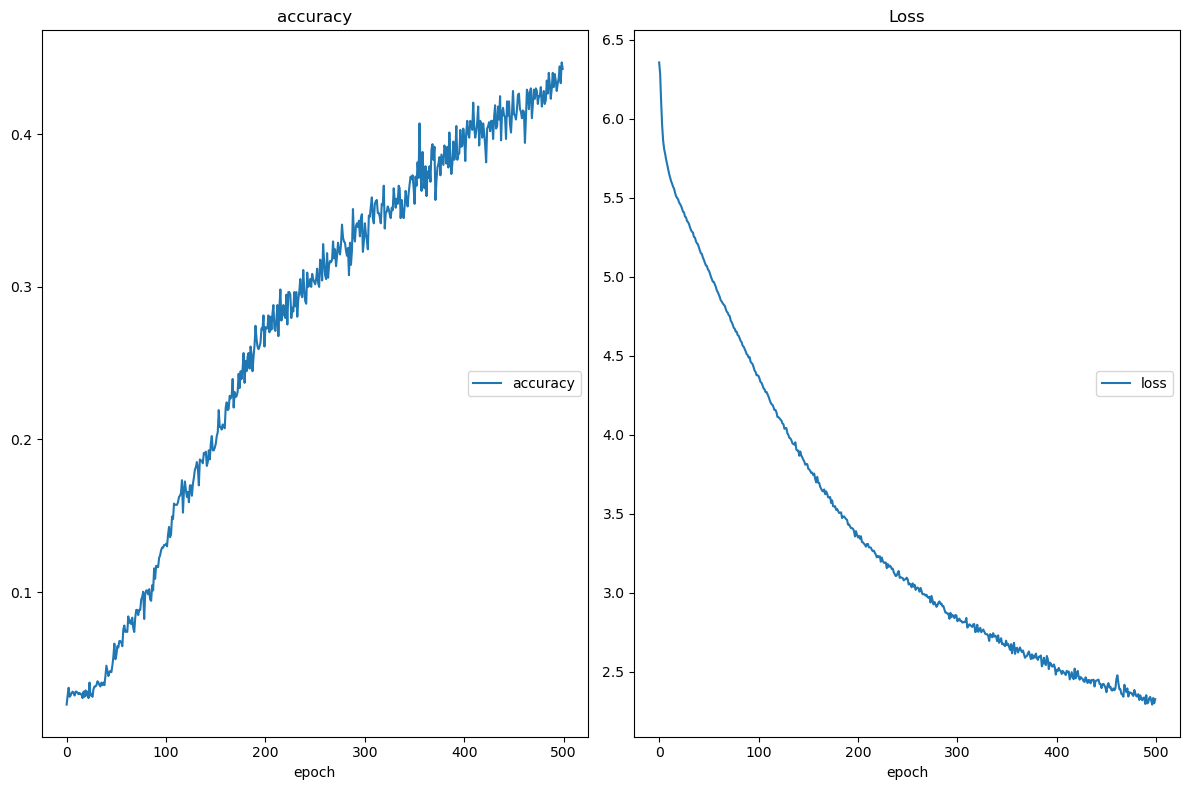

accuracy
	accuracy         	 (min:    0.026, max:    0.447, cur:    0.443)
Loss
	loss             	 (min:    2.292, max:    6.357, cur:    2.326)
37/37 [==============================] - 0s 9ms/step - loss: 2.3263 - accuracy: 0.4427


In [54]:
model.fit(x, y,
          callbacks=[PlotLossesKeras()],
          epochs = 500) 

## 10. Evaluate the Model

In [56]:
scores = model.evaluate(x, y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

accuracy: 54.89%


In [58]:
_list=[np.argmax(model.predict(x[3:4]))]
for k, v in tokens.items():    
    if v in _list:
        print("The next word is: ",k)

1/1 [==============================] - 0s 296ms/step
The next word is:  desire


## The model predicts the next word with around 55% accuracy.  Not that great, and it looks like we are maxing out with the current architecture. Let's try to improve this model

In [60]:
# Create a better Model

model_1 = Sequential()

model_1.add(Embedding(input_dim = vocabulary_size, 
                    output_dim = 100,
                    input_shape = (sequence_length - 1,))) # input_dim

model_1.add(LSTM(units = 100)) # Increased from 10 to 100 - Not enough nodes to handle the patterns

model_1.add(Dropout(rate=0.1))

model_1.add(Dense(units=vocabulary_size, activation ='softmax'))

model_1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 9, 100)            58100     
                                                                 
 lstm_1 (LSTM)               (None, 100)               80400     
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense_1 (Dense)             (None, 581)               58681     
                                                                 
Total params: 197181 (770.24 KB)
Trainable params: 197181 (770.24 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [61]:
model_1.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

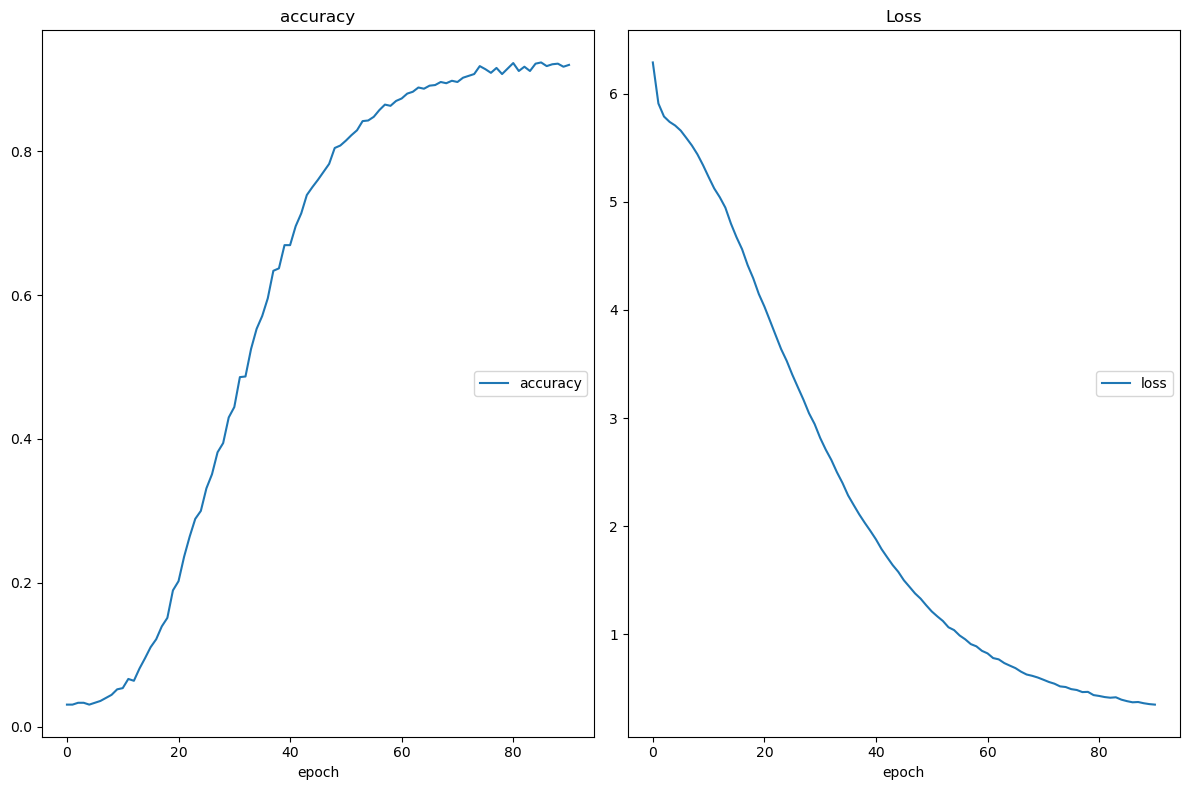

accuracy
	accuracy         	 (min:    0.031, max:    0.924, cur:    0.920)
Loss
	loss             	 (min:    0.351, max:    6.287, cur:    0.351)
37/37 [==============================] - 0s 10ms/step - loss: 0.3515 - accuracy: 0.9201


In [62]:
from keras.callbacks import EarlyStopping

callbacks = EarlyStopping(monitor = 'accuracy',
                          min_delta = 0.001,
                          patience = 10, 
                          verbose = 0,
                          mode = "auto")

model_1.fit(x, y,
          callbacks=[PlotLossesKeras(), callbacks],
          epochs = 200) 

In [63]:
scores = model_1.evaluate(x, y, verbose=0)
print("%s: %.2f%%" % (model_1.metrics_names[1], scores[1]*100))

accuracy: 93.12%


## Now it is up to 93% after a little bit of optimization. That's better!

In [71]:
x_test = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 581]])
_list=[np.argmax(model_1.predict(x_test))]
for k, v in tokens.items():    
    if v in _list:
        print("The next word is: ",k)

1/1 [==============================] - 0s 20ms/step
The next word is:  carved
